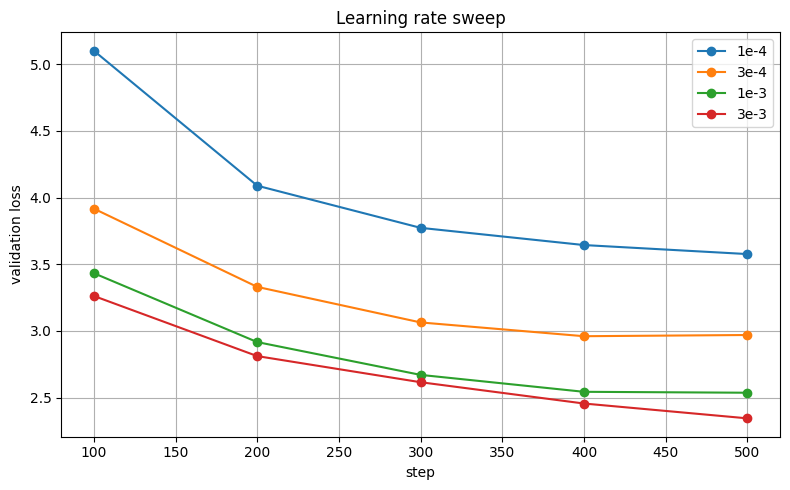

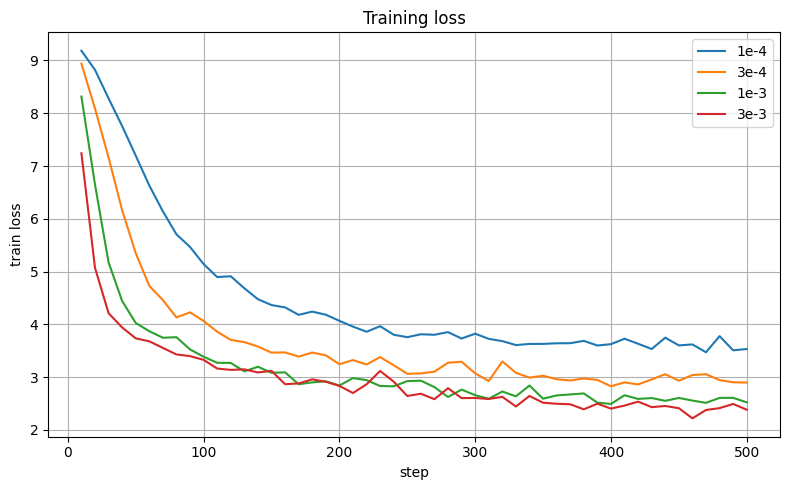

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path("/home/hapi/cs336/assignment1-basics")

runs = {
    "1e-4": root / "runs/lr_1e-04/metrics.csv",
    "3e-4": root / "runs/lr_3e-04/metrics.csv",
    "1e-3": root / "runs/lr_1e-03/metrics.csv",
    "3e-3": root / "runs/lr_3e-03/metrics.csv",
}

plt.figure(figsize=(8, 5))

for name, path in runs.items():
    if not path.exists():
        print(f"skip {name}: {path} not found")
        continue

    df = pd.read_csv(path)
    val = df[df["val_loss"].notna()]

    plt.plot(val["step"], val["val_loss"], marker="o", label=name)

plt.xlabel("step")
plt.ylabel("validation loss")
plt.title("Learning rate sweep")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

for name, path in runs.items():
    if not path.exists():
        continue

    df = pd.read_csv(path)
    train = df[df["train_loss"].notna()]

    plt.plot(train["step"], train["train_loss"], label=name)

plt.xlabel("step")
plt.ylabel("train loss")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [1]:
import time
import numpy as np
import torch

from cs336_basics.transformer import TransformerLM
from cs336_basics.loss import cross_entropy
from cs336_basics.optim import AdamW, gradient_clipping
from cs336_basics.data import data_loading

# 这个实验的核心是：只取一个固定 minibatch，然后反复训练同一批数据。
# 如果模型、loss、optimizer、反向传播都没问题，loss 应该能明显下降，最好降到接近 0。
def global_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += torch.sum(p.grad.detach() ** 2).item()
    return total ** 0.5


def single_batch_overfit():
    torch.manual_seed(0)
    np.random.seed(0)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float32

    train_data = np.load(
        "/home/hapi/cs336/assignment1-basics/data/train.npy",
        mmap_mode="r",
    )

    vocab_size = 10000
    context_length = 64
    batch_size = 4

    # 固定一个 batch，只取一次，后面反复训练它
    inputs, labels = data_loading(
        train_data,
        batch_size=batch_size,
        context_length=context_length,
        device=device,
    )

    model = TransformerLM(
        d_model=128,
        num_heads=4,
        d_ff=512,
        theta=10000.0,
        vocab_size=vocab_size,
        context_length=context_length,
        num_layers=2,
        dtype=dtype,
        device=device,
    )

    optimizer = AdamW(
        model.parameters(),
        lr=3e-3,
        betas=(0.9, 0.95),
        eps=1e-8,
        weight_decay=0.0,
    )

    model.train()
    start = time.time()

    for step in range(1, 1001):
        optimizer.zero_grad(set_to_none=True)

        logits = model(inputs)
        loss = cross_entropy(logits, labels)

        loss.backward()

        grad_norm = global_grad_norm(model)
        gradient_clipping(model.parameters(), max_l2_norm=1.0)

        optimizer.step()

        if step % 20 == 0 or step == 1:
            print(
                f"step {step:4d} | "
                f"loss {loss.item():.6f} | "
                f"grad_norm {grad_norm:.3f} | "
                f"time {time.time() - start:.1f}s"
            )

        if loss.item() < 0.05:
            print(f"success: loss reached {loss.item():.6f} at step {step}")
            break

    return model, inputs, labels


model, inputs, labels = single_batch_overfit()

step    1 | loss 9.208186 | grad_norm 0.815 | time 0.7s
step   20 | loss 1.170360 | grad_norm 0.987 | time 1.0s
success: loss reached 0.047779 at step 35


下面是变化batch

In [4]:
# cd /home/hapi/cs336/assignment1-basics
# uv run python -m cs336_basics.scripts.run_batch_size_sweep

With fixed 500 training steps, larger batch sizes processed more tokens and achieved lower validation loss. Batch size 256 reached the best validation loss among tested settings, and no GPU OOM occurred up to 256. For a stricter comparison of optimization behavior, learning curves should be plotted against tokens processed rather than steps.

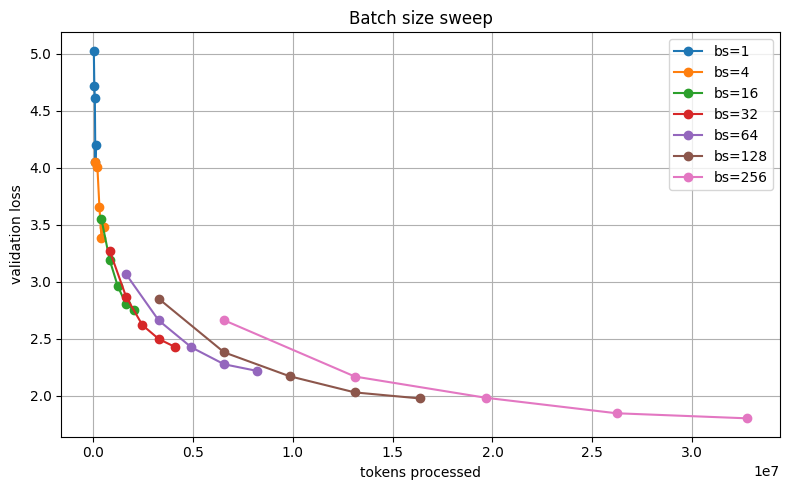

In [5]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = Path("/home/hapi/cs336/assignment1-basics")
run_root = root / "runs/batch_size_sweep"

plt.figure(figsize=(8, 5))

for metrics_path in sorted(run_root.glob("bs_*/metrics.csv")):
    config_path = metrics_path.parent / "config.json"

    with open(config_path) as f:
        config = json.load(f)

    batch_size = config["batch_size"]

    df = pd.read_csv(metrics_path)
    val = df[df["val_loss"].notna()]

    plt.plot(
        val["tokens_processed"],
        val["val_loss"],
        marker="o",
        label=f"bs={batch_size}",
    )

plt.xlabel("tokens processed")
plt.ylabel("validation loss")
plt.title("Batch size sweep")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

用gpu和bf16跑的实验

bs=32   约 83k tokens/s
bs=64   约 73k tokens/s
bs=128  约 16k tokens/s
bs=256  约 9k tokens/s


在固定训练步数为 500 steps、学习率为 3e-3 的设置下，batch size 越大，每一步处理的 token 数越多，因此总训练 token 数也越多，最终 validation loss 明显更低。实验中，batch size 从 1 增加到 256 时，validation loss 从约 4.20 降低到约 1.80，perplexity 也从约 66.5 降低到约 6.1。说明在这个设置下，更大的 batch size 带来了更稳定、更有效的训练。

不过你也要加一句限制：

但这个比较并不是完全公平的，因为不同 batch size 在相同 step 数下处理的 token 总量不同。batch size 256 在 500 steps 中处理了约 3277 万 tokens，而 batch size 1 只处理了 12.8 万 tokens。因此，分析 learning curves 时更应该使用 tokens_processed 作为横轴，而不是只使用 step。

再加一句和作业要求相关的：

本实验覆盖了 batch size 1、4、16、32、64、128、256，其中包含作业要求中特别提到的 64 和 128。所有这些 batch size 都可以在当前 GPU 上运行，尚未达到显存上限。

我建议你后面正式 low-resource 训练就跑：

batch_size = 32
dtype = torch.float32
device = "cuda"
total_steps = 5000
context_length = 256


这样刚好对应作业 low-resource tip 里的 token 数：

32 × 5000 × 256 = 40,960,000 tokens

使用 low-resource 配置 batch_size=32, context_length=256, total_steps=5000，模型总共处理了 40,960,000 tokens。在 CUDA 上使用 float32 训练约 13.9 分钟，最终 validation loss 达到 1.6368，perplexity 为 5.14。loss 曲线整体稳定下降，说明训练过程正常收敛。

在相同的 low-resource 设置下，1e-3 和 3e-3 都能稳定训练，但 3e-3 的最终 validation loss 更低。1e-3 在 40.96M tokens 后达到 1.7187，而 3e-3 达到 1.6368，说明 1e-3 对该配置偏保守，收敛速度较慢。因此后续正式实验采用 3e-3 作为 peak learning rate。

2e-3 和 3e-3 都能稳定训练，并且最终 validation loss 都明显低于 low-resource 目标。2e-3 的最低验证损失达到 1.6238，但最终 step 5000 回升到 1.6698；3e-3 最终达到 1.6368，曲线末端仍然较稳定。因此我选择 3e-3 作为正式 peak learning rate，同时认为 2e-3 和 3e-3 表现非常接近。

在 low-resource 设置下，我比较了 2e-3 和 3e-3。两者都稳定收敛，最终 validation loss 都约在 1.67-1.69 附近。2e-3 在本次实验中取得了略低的 validation loss，因此我将其视为更稳健的选择；不过二者差距较小，可能受到 validation batch 采样噪声影响。

下面是生成文本

In [6]:
import torch

from cs336_basics.transformer import TransformerLM
from cs336_basics.Tokenizer import Tokenizer
from cs336_basics.decoding import Decoding


device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint_path = "/home/hapi/cs336/assignment1-basics/runs/batch_size_sweep/bs_032_lr_3e-03TOTAL_STEPS=5000/checkpoint.pt"

vocab_path = "/home/hapi/cs336/assignment1-basics/artifacts/tinystories_bpe_increase_vocab_10000.pkl"
merges_path = "/home/hapi/cs336/assignment1-basics/artifacts/tinystories_bpe_increase_merges_10000.pkl"

tokenizer = Tokenizer.from_files(
    vocab_path,
    merges_path,
    special_tokens=["<|endoftext|>"],
)

model = TransformerLM(
    d_model=512,
    num_heads=16,
    d_ff=1344,
    theta=10000.0,
    vocab_size=10000,
    context_length=256,
    num_layers=4,
    dtype=torch.float32,
    device=device,
)

checkpoint = torch.load(checkpoint_path, map_location=device)

# 因为训练时用了 torch.compile(model)，保存的 key 前面有 "_orig_mod."
state_dict = {
    key.removeprefix("_orig_mod."): value
    for key, value in checkpoint["model"].items()
}

model.load_state_dict(state_dict)
model.eval()

print("loaded checkpoint step:", checkpoint["iteration"])

loaded checkpoint step: 5000


In [8]:
text = Decoding(
    model=model,
    context_length=256,
    tokenizer=tokenizer,
    prompt="Once upon a time,",
    max_generated_tokens=200,
    temperature=0.8,
    Top_p=0.9,
    device=device,
)

print(text)

Once upon a time, there was a little boy named Tim. He had a dog named Max. Tim and Max liked to play together. One day, Tim was very hungry. He wanted to find some food.
Tim and Max walked around the park. They saw a big tree. Max said, "Let's go to the tree and look for food!" Tim agreed, and they went to the tree.
Tim and Max found a big, red apple. They took a bite and it was very tasty. Tim and Max were very happy. They ate the apple and had a great day.
<|endoftext|>


Once upon a time, there was a little boy named Tim. Tim loved to play in his backyard. One day, he saw a big tree with a long rope hanging from it. He wanted to play with it.
Tim tried to reach the rope, but he was too small. He tried to climb the tree, but he was too small. He asked his friend, Sam, for help. Sam was tall and strong. They tried together, but they could not reach the rope.
Finally, they saw a



优点：

语法基本正确。
故事开头自然：Once upon a time...
人物、场景、目标都清楚：Tim、backyard、tree、rope。
有重复结构，像 TinyStories 里的儿童故事风格。
没有乱码、奇怪 token、无意义单词。
句子之间连贯，模型知道继续讲一个“小孩想拿绳子”的故事。
不足：

有一点重复：
but he was too small
出现了两次。TinyStories 模型常见。

故事还没完整结束，最后停在：
Finally, they saw a
说明 max_generated_tokens 可能不够，或者没有生成到自然结束。

情节比较简单，还没有明显结尾或 moral。

设最大200上下文
Once upon a time, there was a little boy named Tim. He had a dog named Max. Tim and Max liked to play together. One day, Tim was very hungry. He wanted to find some food.
Tim and Max walked around the park. They saw a big tree. Max said, "Let's go to the tree and look for food!" Tim agreed, and they went to the tree.
Tim and Max found a big, red apple. They took a bite and it was very tasty. Tim and Max were very happy. They ate the apple and had a great day.
<|endoftext|>


这个样本整体质量较好。模型生成了一个完整的小故事，包含人物、目标和结尾，并且自动生成了 <|endoftext|> 作为文档结束符。文本语法基本正确，符合 TinyStories 的简单儿童故事风格。缺点是人物名和短语有一定重复，情节也比较简单，但作为 low-resource 训练结果已经较好。







In [ ]:
# cd /home/hapi/cs336/assignment1-basics
# uv run python -m cs336_basics.scripts.run_no_rmsnorm